# 04 — ABCD background-estimation machinery with `base_old`

이 notebook은 최종 SR/VR 물리 결과가 아니라 ABCD background-estimation 파이프라인과 플롯 스토리라인을 검증한다. `base` 채널로 생산된 기존 Data/BKG histogram을 사용하며, 최종 SR/VR 산출물이 준비되면 동일 machinery를 `05` notebook에서 재사용한다.

스토리라인: **입력 검증 → ABCD plane → region composition → prediction/closure → working-point stability → correlation → Data prediction → summary**.


In [1]:
from pathlib import Path
import sys

# coffea outputs contain sidm histogram classes, so make the repository package importable.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "sidm" / "__init__.py").exists():
        sys.path.insert(0, str(candidate))
        break

import coffea.util
from coffea import processor
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from sidm.tools import llpnanoaodschema, sidm_processor, utilities

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)


## 1. Configuration, luminosity normalization, and blinding

`base_old` Data는 DoubleMuon 2018A+C의 21.89 fb$^{-1}$만 포함한다. 저장된 MC는 full-2018 59.83 fb$^{-1}$ 기준이므로 모든 background histogram을 $21.89/59.83=0.365848$배 한다. 이 공통 보정은 absolute yield와 Data/MC 비교를 맞추며 MC closure ratio에는 영향을 주지 않는다. Signal과 Data에는 적용하지 않는다.


In [2]:
OUTPUT_DIR = Path("base_old")
CHANNEL = "base"
UNBLIND_DATA_A = False
DATA_LUMI = 21.89  # fb^-1, available DoubleMuon 2018A+C exposure
FULL_2018_LUMI = 59.83  # fb^-1 used to normalize the stored MC outputs
MC_LUMI_SCALE = DATA_LUMI / FULL_2018_LUMI  # 0.36584823474333794

HIST_CONFIGS = {
    "mulj_egmlj_iso": {
        "topology": "2mu2e-like",
        "cuts": (0.25, 0.10),
        "x_label": r"$I_{\mu LJ}$",
        "y_label": r"$I_{e/\gamma LJ}$",
    },
    "mulj_mulj_iso": {
        "topology": "4mu-like",
        "cuts": (0.25, 0.25),
        "x_label": r"leading $I_{\mu LJ}$",
        "y_label": r"subleading $I_{\mu LJ}$",
    },
}

GROUP_ORDER = ["QCD", "DY", "TTJets", "Diboson", "BKG total", "Data"]
MC_GROUPS = {"QCD", "DY", "TTJets", "Diboson", "BKG total"}
SIGNAL_SAMPLES = {
    "2Mu2E_500GeV_0p25GeV_2p0mm": "signal_2mu2e_v10.yaml",
    "4Mu_500GeV_0p25GeV_2p0mm": "signal_4mu_v10.yaml",
}
SIGNAL_CACHE = Path("base_test_signals_full")
PROCESS_SIGNALS_IF_MISSING = False  # full caches are loaded automatically
GROUP_COLORS = {
    "QCD": "#4c78a8", "DY": "#f58518", "TTJets": "#54a24b",
    "Diboson": "#e45756", "BKG total": "black", "Data": "black",
}
SCAN_VALUES = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])

print(f"Input: {OUTPUT_DIR.resolve()}")
print(f"Channel: {CHANNEL}; unblind Data A: {UNBLIND_DATA_A}")
print(f"MC luminosity correction: {MC_LUMI_SCALE:.12f} ({FULL_2018_LUMI:.2f} -> {DATA_LUMI:.2f} fb^-1)")


Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/base_old
Channel: base; unblind Data A: False
MC luminosity correction: 0.365869964901 (59.83 -> 21.89 fb^-1)


## 2. Load outputs and build physics groups


In [3]:
def classify_sample(name):
    if name.startswith("DoubleMuon"):
        return "Data"
    if name.startswith("QCD_"):
        return "QCD"
    if name.startswith(("DYJetsToMuMu", "DYJetsToLL")):
        return "DY"
    if name.startswith("TTJets"):
        return "TTJets"
    if name in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    return "Other"


def load_outputs(directory):
    outputs, audit = {}, []
    for path in sorted(directory.glob("*.coffea")):
        try:
            loaded = coffea.util.load(path)
            out = loaded.get("out", loaded)
            if not isinstance(out, dict) or not out:
                raise ValueError("no non-empty 'out' mapping")
            for internal_name, payload in out.items():
                label = path.stem if len(out) == 1 else f"{path.stem}:{internal_name}"
                outputs[label] = payload
                available = sorted(set(HIST_CONFIGS) & set(payload.get("hists", {})))
                audit.append({
                    "file": path.name, "sample": label,
                    "internal_key": internal_name, "status": "loaded",
                    "group": classify_sample(path.stem),
                    "ABCD_hists": ", ".join(available),
                })
        except Exception as exc:
            audit.append({"file": path.name, "sample": None, "internal_key": None,
                          "status": f"ERROR: {exc}", "group": None, "ABCD_hists": ""})
    return outputs, pd.DataFrame(audit)


outputs, load_audit = load_outputs(OUTPUT_DIR)
sample_groups = {}
for sample in outputs:
    group = classify_sample(sample.split(":")[0])
    sample_groups.setdefault(group, []).append(sample)
background_samples = sum((sample_groups.get(g, []) for g in ["QCD", "DY", "TTJets", "Diboson"]), [])
sample_groups["BKG total"] = background_samples
display(load_audit)
print({group: len(samples) for group, samples in sample_groups.items()})


,file,sample,internal_key,status,group,ABCD_hists
0,DYJetsToMuMu_M10to50.coffea,DYJetsToMuMu_M10to50,DYJetsToMuMu_M10to50,loaded,DY,"mulj_egmlj_iso, mulj_mulj_iso"
1,DYJetsToMuMu_M50.coffea,DYJetsToMuMu_M50,DYJetsToMuMu_M50,loaded,DY,"mulj_egmlj_iso, mulj_mulj_iso"
2,DoubleMuon_2018A_0.coffea,DoubleMuon_2018A_0,DoubleMuon_2018A_0,loaded,Data,"mulj_egmlj_iso, mulj_mulj_iso"
3,DoubleMuon_2018A_1.coffea,DoubleMuon_2018A_1,DoubleMuon_2018A_1,loaded,Data,"mulj_egmlj_iso, mulj_mulj_iso"
4,DoubleMuon_2018A_2.coffea,DoubleMuon_2018A_2,DoubleMuon_2018A_2,loaded,Data,"mulj_egmlj_iso, mulj_mulj_iso"
5,DoubleMuon_2018C.coffea,DoubleMuon_2018C,DoubleMuon_2018C,loaded,Data,"mulj_egmlj_iso, mulj_mulj_iso"
6,QCD_Pt1000.coffea,QCD_Pt1000,QCD_Pt1000,loaded,QCD,"mulj_egmlj_iso, mulj_mulj_iso"
7,QCD_Pt120To170.coffea,QCD_Pt120To170,QCD_Pt120To170,loaded,QCD,"mulj_egmlj_iso, mulj_mulj_iso"
8,QCD_Pt15To20.coffea,QCD_Pt15To20,QCD_Pt15To20,loaded,QCD,"mulj_egmlj_iso, mulj_mulj_iso"
9,QCD_Pt170To300.coffea,QCD_Pt170To300,QCD_Pt170To300,loaded,QCD,"mulj_egmlj_iso, mulj_mulj_iso"


{'DY': 2, 'Data': 4, 'QCD': 12, 'TTJets': 1, 'Diboson': 3, 'BKG total': 18}


### Full-run signal benchmarks

두 topology 이름은 truth label이 아니라 reconstruction-level histogram 구성에서 온다. `mulj_egmlj_iso`는 muLJ–egmLJ 쌍이므로 **2mu2e-like**, `mulj_mulj_iso`는 muLJ–muLJ 쌍이므로 **4mu-like**라고 부른다. 아래 benchmark는 이 해석과 plotting pipeline을 검증하기 위한 overlay이며 background prediction에는 포함하지 않는다.

두 benchmark의 전체-file 결과는 `base_test_signals_full/`에서 자동으로 읽는다. cache를 다시 만들 때만 configuration cell의 `PROCESS_SIGNALS_IF_MISSING = True`로 바꾼 뒤 바로 아래 cell을 실행한다. `max_files=-1`이므로 모든 ROOT 파일을 처리한다.


In [4]:
def process_or_load_signal(sample, location_cfg):
    SIGNAL_CACHE.mkdir(exist_ok=True)
    cache_path = SIGNAL_CACHE / f"{sample}.coffea"
    if cache_path.exists():
        cached = coffea.util.load(cache_path)
        return cached["out"][sample]
    if not PROCESS_SIGNALS_IF_MISSING:
        return None

    fileset = utilities.make_fileset(
        [sample], "llpNanoAOD_v2", max_files=-1, location_cfg=location_cfg,
    )
    runner = processor.Runner(
        executor=processor.IterativeExecutor(),
        schema=llpnanoaodschema.LLPNanoAODSchema,
        skipbadfiles=False,
    )
    proc = sidm_processor.SidmProcessor(
        [CHANNEL], ["abcd_iso_base"], unweighted_hist=False,
    )
    result = runner(fileset, treename="Events", processor_instance=proc)
    coffea.util.save({"out": result}, cache_path)
    return result[sample]


loaded_signals = []
for signal, location_cfg in SIGNAL_SAMPLES.items():
    payload = process_or_load_signal(signal, location_cfg)
    if payload is not None:
        outputs[signal] = payload
        sample_groups[signal] = [signal]
        loaded_signals.append(signal)
print("Loaded signal benchmarks:", loaded_signals)


Loaded signal benchmarks: ['2Mu2E_500GeV_0p25GeV_2p0mm', '4Mu_500GeV_0p25GeV_2p0mm']


### Histogram access helpers

모든 후속 계산은 아래 두 함수만 통해 입력을 받는다. 따라서 `05`에서는 loader 또는 channel만 교체하고 나머지 machinery를 그대로 사용할 수 있다.


In [5]:
def sample_hist(sample, hist_name, channel=CHANNEL):
    hist = outputs[sample]["hists"][hist_name]
    if "channel" in hist.axes.name:
        hist = hist[{"channel": channel}]
    return hist


def group_hist(group, hist_name, channel=CHANNEL):
    hists = []
    for sample in sample_groups.get(group, []):
        try:
            hists.append(sample_hist(sample, hist_name, channel))
        except (KeyError, ValueError):
            pass
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    if group in MC_GROUPS:
        total = total * MC_LUMI_SCALE
    return total


def hist_values_variances(h2d):
    values = np.asarray(h2d.values(flow=False), dtype=float)
    variances = h2d.variances(flow=False)
    if variances is None:
        variances = np.clip(values, 0, None)
    return values, np.asarray(variances, dtype=float)


## 3. Introduce the ABCD planes


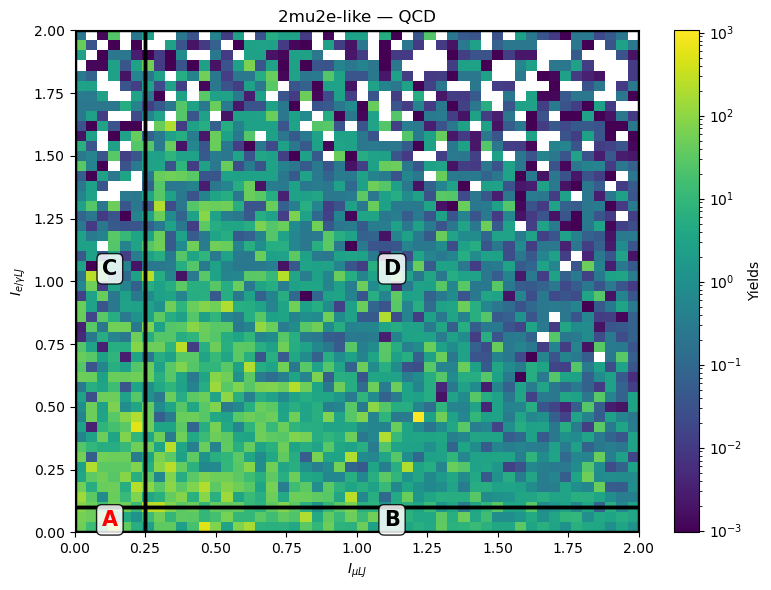

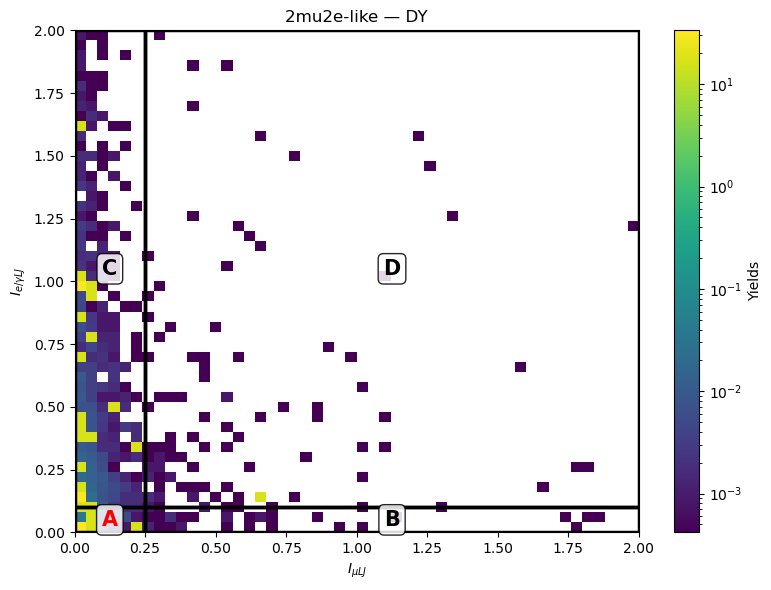

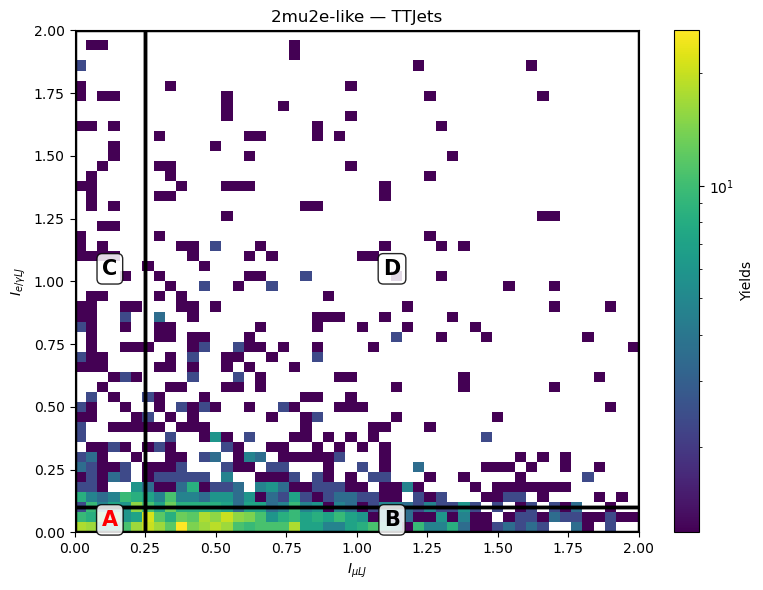

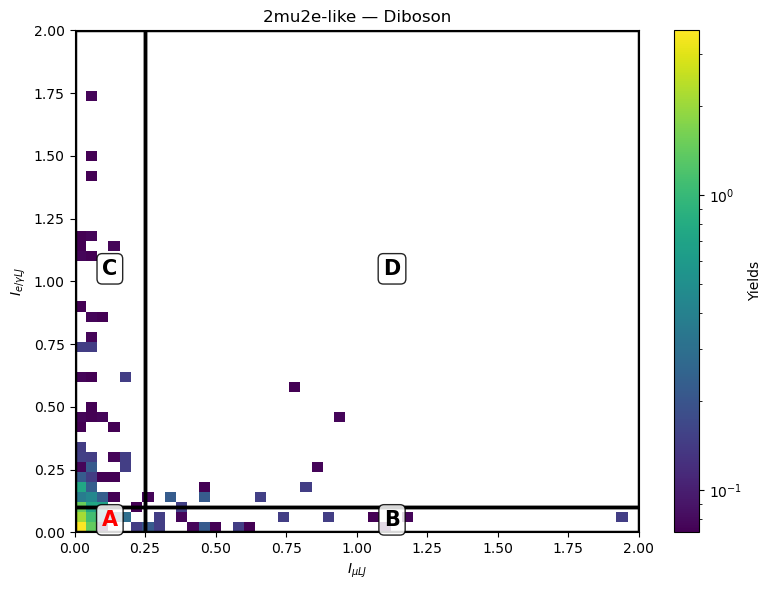

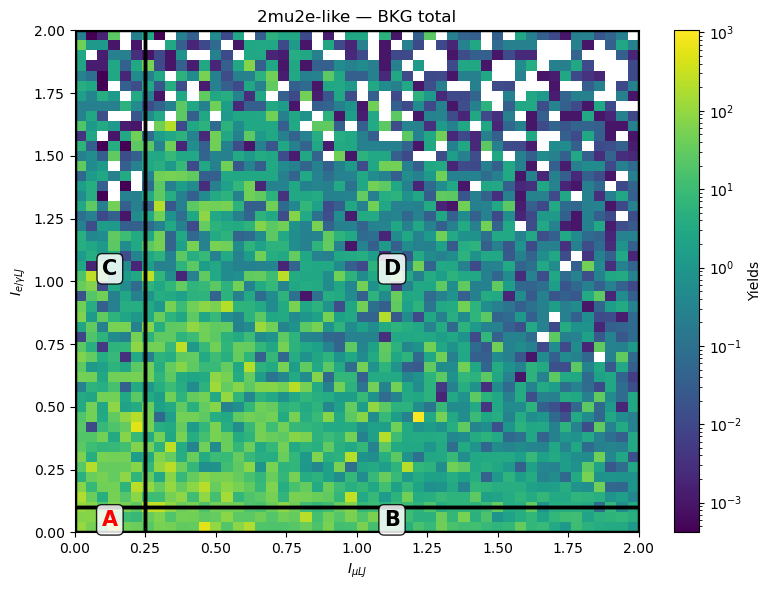

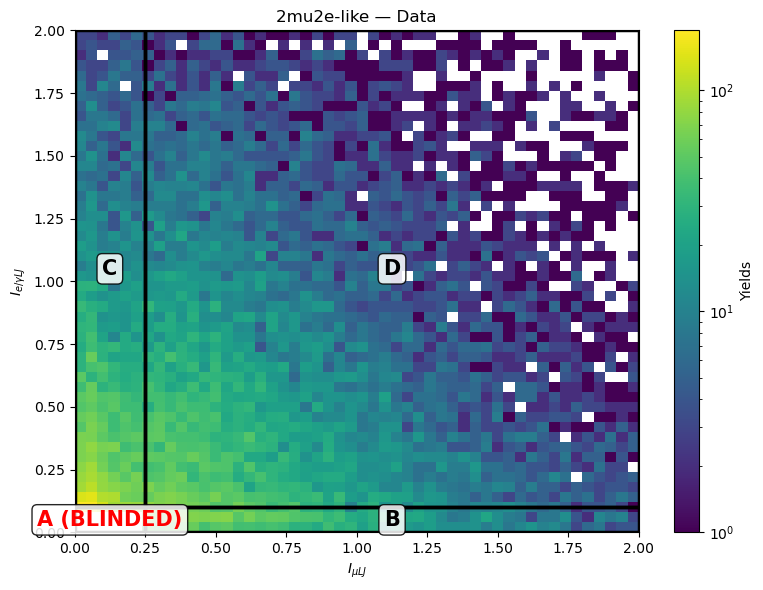

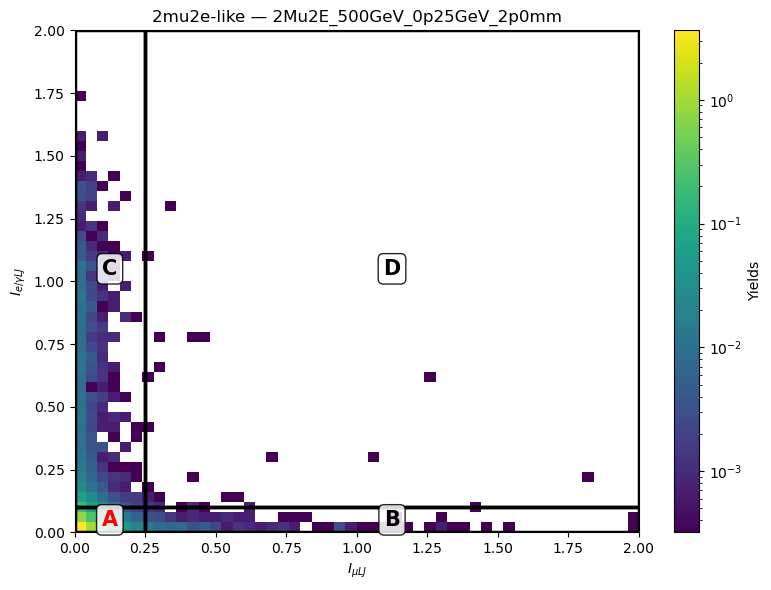

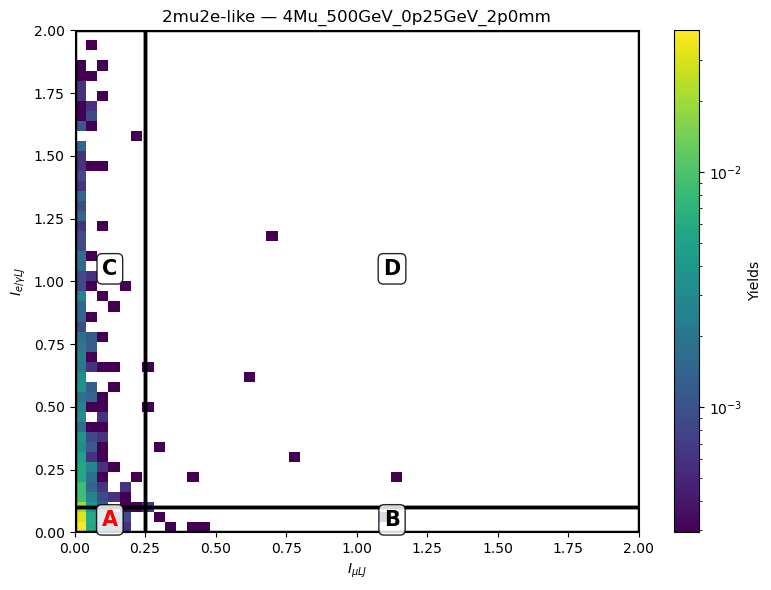

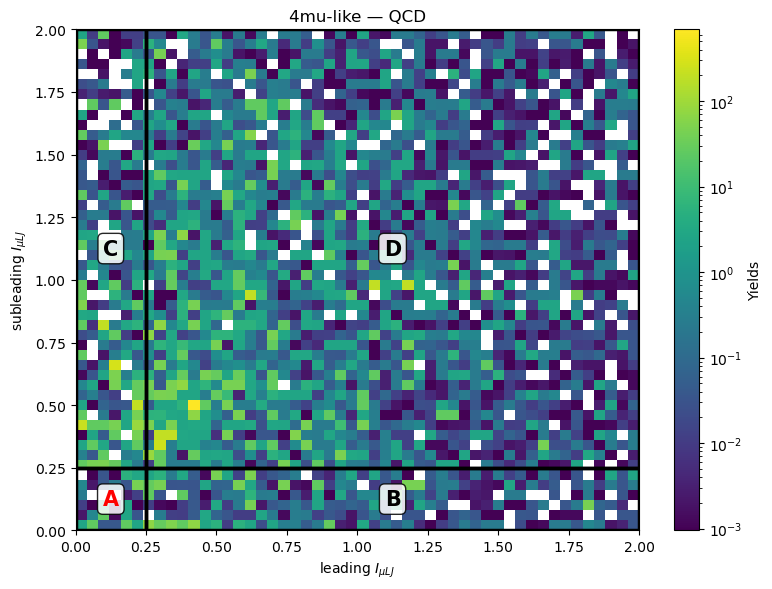

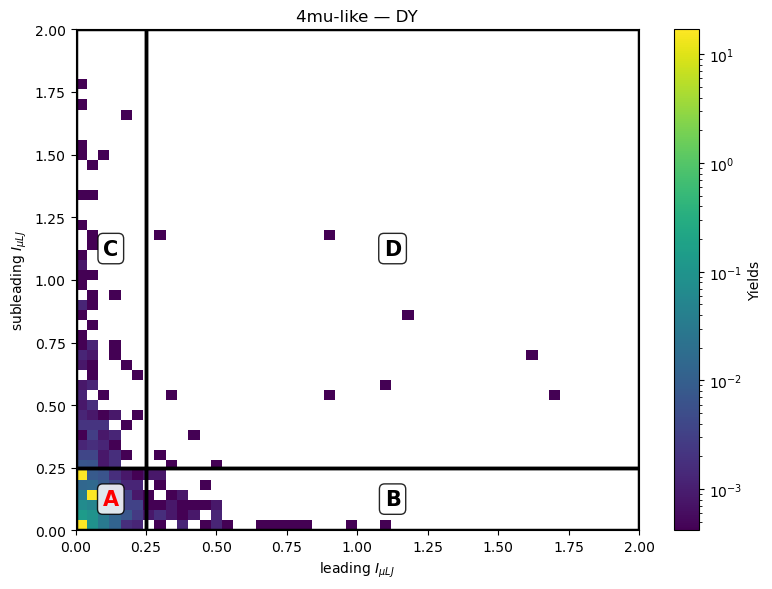

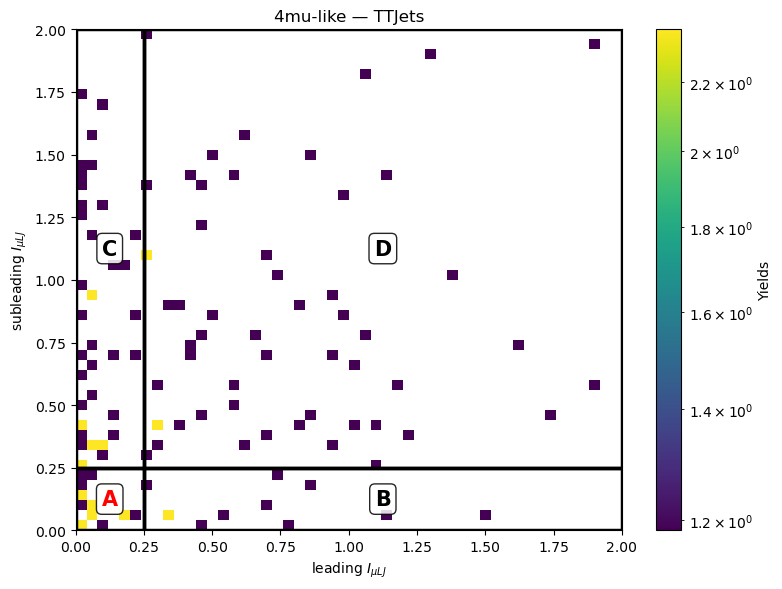

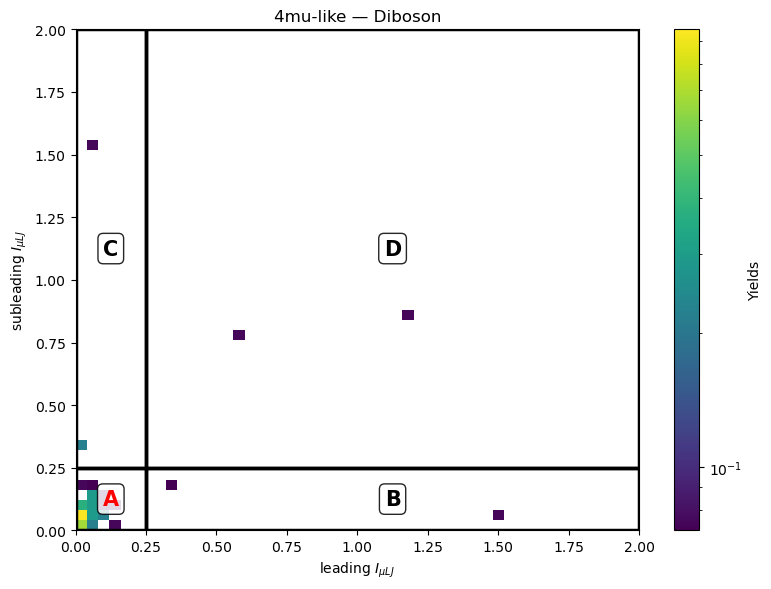

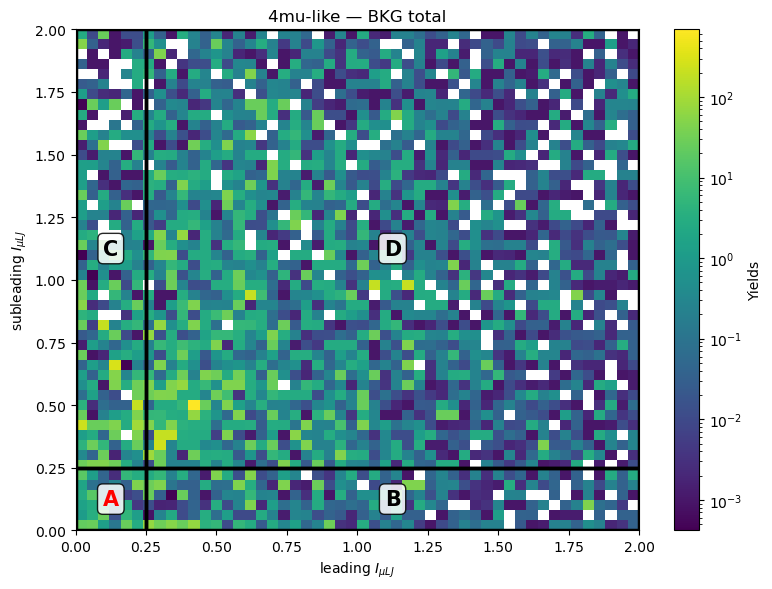

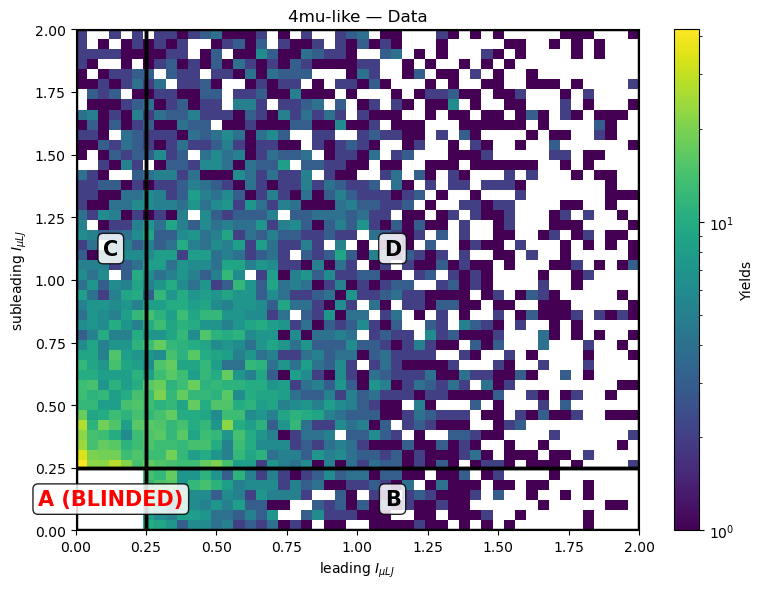

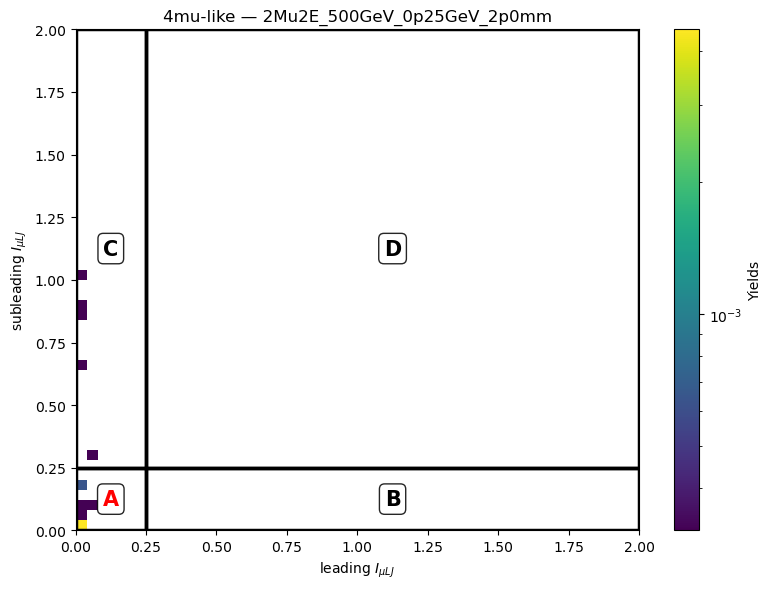

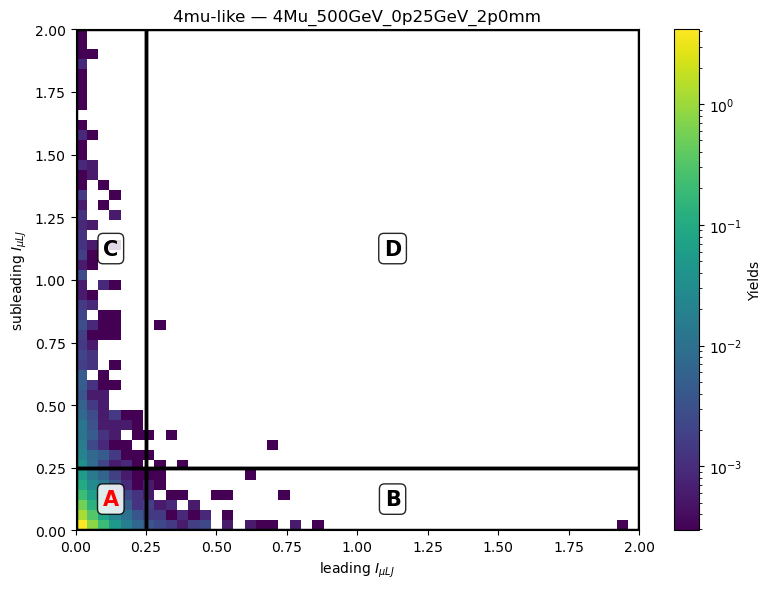

In [6]:
def plot_abcd_plane(h2d, title, cuts, labels, log=True, blind_a=False):
    values, _ = hist_values_variances(h2d)
    xcut, ycut = cuts
    if blind_a:
        values = values.copy()
        xcenters = np.asarray(h2d.axes[0].centers)[:, None]
        ycenters = np.asarray(h2d.axes[1].centers)[None, :]
        values[(xcenters < xcut) & (ycenters < ycut)] = np.nan
    xedges, yedges = h2d.axes[0].edges, h2d.axes[1].edges
    positive = values[values > 0]
    norm = LogNorm(vmin=max(positive.min(), 1e-6), vmax=positive.max()) if log and positive.size else None
    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(xedges, yedges, values.T, shading="auto", cmap="viridis", norm=norm)
    xmin, xmax = xedges[0], xedges[-1]
    ymin, ymax = yedges[0], yedges[-1]
    bounds = {
        "A": (xmin, ymin, xcut-xmin, ycut-ymin),
        "B": (xcut, ymin, xmax-xcut, ycut-ymin),
        "C": (xmin, ycut, xcut-xmin, ymax-ycut),
        "D": (xcut, ycut, xmax-xcut, ymax-ycut),
    }
    for region, (left, bottom, width, height) in bounds.items():
        ax.add_patch(Rectangle((left, bottom), width, height, fill=False, edgecolor="black", lw=2.5))
        x, y = left + width/2, bottom + height/2
        color = "red" if region == "A" else "black"
        label = "A (BLINDED)" if region == "A" and blind_a else region
        ax.text(x, y, label, color=color, fontsize=15, weight="bold", ha="center", va="center",
                bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "round,pad=0.25", "alpha": 0.85})
    ax.set(xlabel=labels[0], ylabel=labels[1], title=title)
    fig.colorbar(mesh, ax=ax, label="Yields")
    fig.tight_layout()
    return fig, ax


for hist_name, cfg in HIST_CONFIGS.items():
    groups = [g for g in ["QCD", "DY", "TTJets", "Diboson", "BKG total", "Data", *loaded_signals]
              if group_hist(g, hist_name) is not None]
    for group in groups:
        plot_abcd_plane(group_hist(group, hist_name), f"{cfg['topology']} — {group}",
                        cfg["cuts"], (cfg["x_label"], cfg["y_label"]),
                        blind_a=(group == "Data" and not UNBLIND_DATA_A))
        plt.show()


## 4. Region yields, composition, and ABCD prediction


In [17]:
def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {"A": (x < xcut) & (y < ycut),
            "B": (x >= xcut) & (y < ycut),
            "C": (x < xcut) & (y >= ycut),
            "D": (x >= xcut) & (y >= ycut)}


def abcd_yields(h2d, cuts, blind_a=False):
    values, variances = hist_values_variances(h2d)
    out = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        if region == "A" and blind_a:
            out[region] = (np.nan, np.nan)
        else:
            out[region] = (values[mask].sum(), np.sqrt(variances[mask].sum()))
    return out


def abcd_prediction(yields):
    b, eb = yields["B"]; c, ec = yields["C"]; d, ed = yields["D"]
    if d <= 0:
        return np.nan, np.nan
    pred = b*c/d
    relvar = sum((e/v)**2 for v, e in [(b, eb), (c, ec), (d, ed)] if v != 0)
    return pred, abs(pred)*np.sqrt(relvar)


def closure_result(h2d, cuts, blind_a=False):
    yields = abcd_yields(h2d, cuts, blind_a=blind_a)
    pred, pred_err = abcd_prediction(yields)
    obs, obs_err = yields["A"]
    ratio = obs/pred if np.isfinite(obs) and pred > 0 else np.nan
    ratio_err = abs(ratio)*np.sqrt((obs_err/obs)**2 + (pred_err/pred)**2) if np.isfinite(obs) and obs > 0 and pred > 0 else np.nan
    return yields, pred, pred_err, ratio, ratio_err


rows = []
for hist_name, cfg in HIST_CONFIGS.items():
    for group in GROUP_ORDER:
        h2d = group_hist(group, hist_name)
        if h2d is None:
            continue
        blind_a = group == "Data" and not UNBLIND_DATA_A
        yields, pred, pred_err, ratio, ratio_err = closure_result(h2d, cfg["cuts"], blind_a=blind_a)
        row = {"topology": cfg["topology"], "histogram": hist_name, "group": group,
               "A_pred": pred, "A_pred_err": pred_err, "closure": ratio, "closure_err": ratio_err}
        for region, (value, error) in yields.items():
            row[region], row[f"{region}_err"] = value, error
        rows.append(row)
abcd_summary = pd.DataFrame(rows)
display(abcd_summary)


,topology,histogram,group,A_pred,A_pred_err,closure,closure_err,A,A_err,B,B_err,C,C_err,D,D_err
0,2mu2e-like,mulj_egmlj_iso,QCD,527.191078,160.858962,1.294780,0.683505,682.596359,294.047631,2169.442232,558.213558,4880.886691,714.088151,20085.320423,1488.125606
1,2mu2e-like,mulj_egmlj_iso,DY,0.280147,0.290267,299.939921,338.396639,84.027268,37.514137,0.013351,0.002360,352.933337,76.881103,16.820224,16.776832
2,2mu2e-like,mulj_egmlj_iso,TTJets,187.413565,17.690990,0.700915,0.093827,131.360889,12.468224,607.100325,26.804134,222.485110,16.226394,720.709743,29.204633
3,2mu2e-like,mulj_egmlj_iso,Diboson,12.584660,4.789605,0.750549,0.294425,9.445410,0.897749,1.842234,0.436006,8.628772,0.844235,1.263142,0.355621
4,2mu2e-like,mulj_egmlj_iso,BKG total,729.143270,182.793774,1.244515,0.512753,907.429927,296.694425,2778.398143,558.856894,5464.933910,718.398636,20824.113532,1488.506741
5,2mu2e-like,mulj_egmlj_iso,Data,1055.889889,25.699479,NaN,NaN,NaN,NaN,2462.000000,49.618545,7673.000000,87.595662,17891.000000,133.757243
6,4mu-like,mulj_mulj_iso,QCD,297.508290,87.380557,0.484706,0.253562,144.203955,62.424999,899.833965,168.560257,2309.958439,449.346276,6986.625685,806.764597
7,4mu-like,mulj_mulj_iso,DY,0.317815,0.116503,161.228439,108.870729,51.240838,29.058332,0.020444,0.002921,0.071346,0.005766,0.004590,0.001504
8,4mu-like,mulj_mulj_iso,TTJets,9.467451,3.466832,2.000000,0.886771,18.934903,4.733726,13.017746,3.924998,47.337257,7.484678,65.088729,8.776562
9,4mu-like,mulj_mulj_iso,Diboson,0.288151,0.322221,13.049925,14.746891,3.760345,0.612459,0.147623,0.104417,0.295246,0.147668,0.151259,0.106956


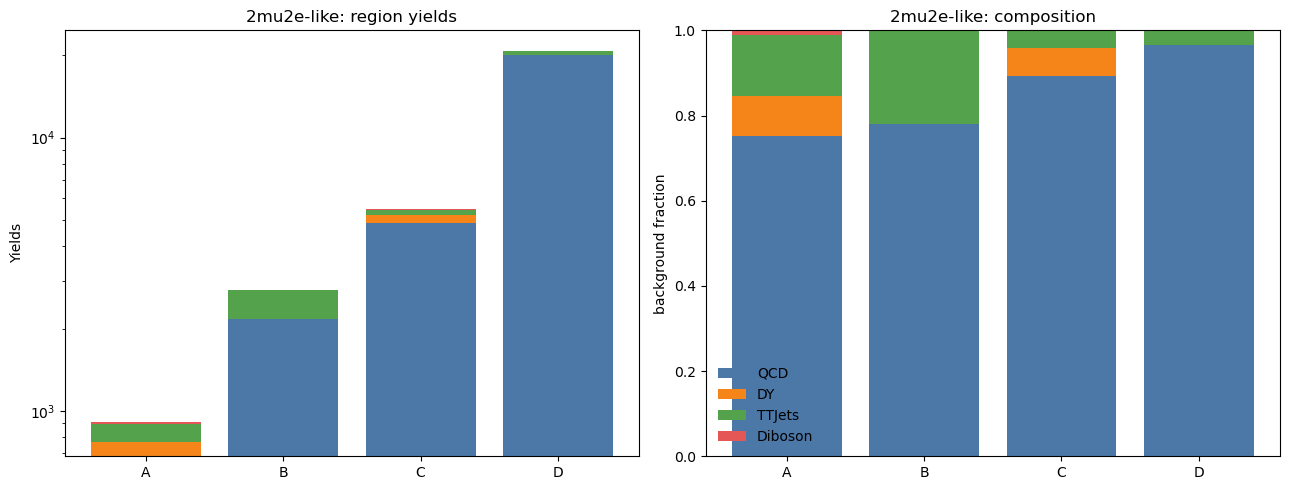

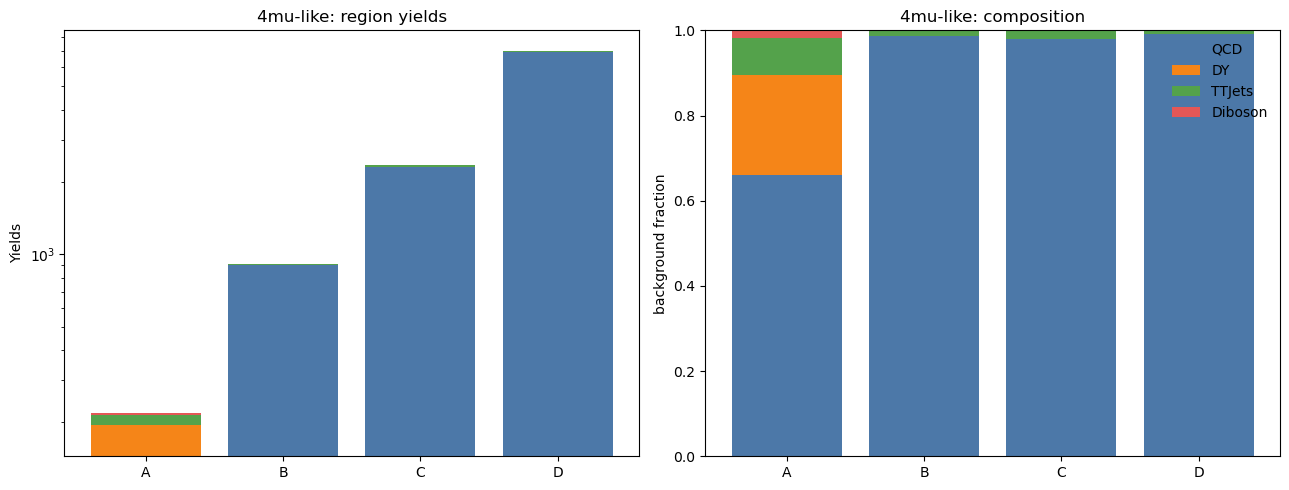

In [18]:
def plot_region_composition(summary, topology):
    frame = summary[(summary.topology == topology) & summary.group.isin(["QCD", "DY", "TTJets", "Diboson"])].copy()
    regions = ["A", "B", "C", "D"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    bottom = np.zeros(len(regions))
    totals = frame[regions].sum(axis=0).to_numpy()
    for group in ["QCD", "DY", "TTJets", "Diboson"]:
        values = frame.loc[frame.group == group, regions].sum(axis=0).to_numpy()
        axes[0].bar(regions, values, bottom=bottom, label=group, color=GROUP_COLORS[group])
        axes[1].bar(regions, np.divide(values, totals, out=np.zeros_like(values), where=totals != 0),
                    bottom=np.divide(bottom, totals, out=np.zeros_like(bottom), where=totals != 0),
                    label=group, color=GROUP_COLORS[group])
        bottom += values
    axes[0].set(ylabel="Yields", title=f"{topology}: region yields")
    axes[0].set_yscale("log")
    axes[1].set(ylabel="background fraction", ylim=(0, 1), title=f"{topology}: composition")
    axes[1].legend(frameon=False)
    fig.tight_layout()


for topology in abcd_summary.topology.unique():
    plot_region_composition(abcd_summary, topology)
    plt.show()


## 5. MC closure


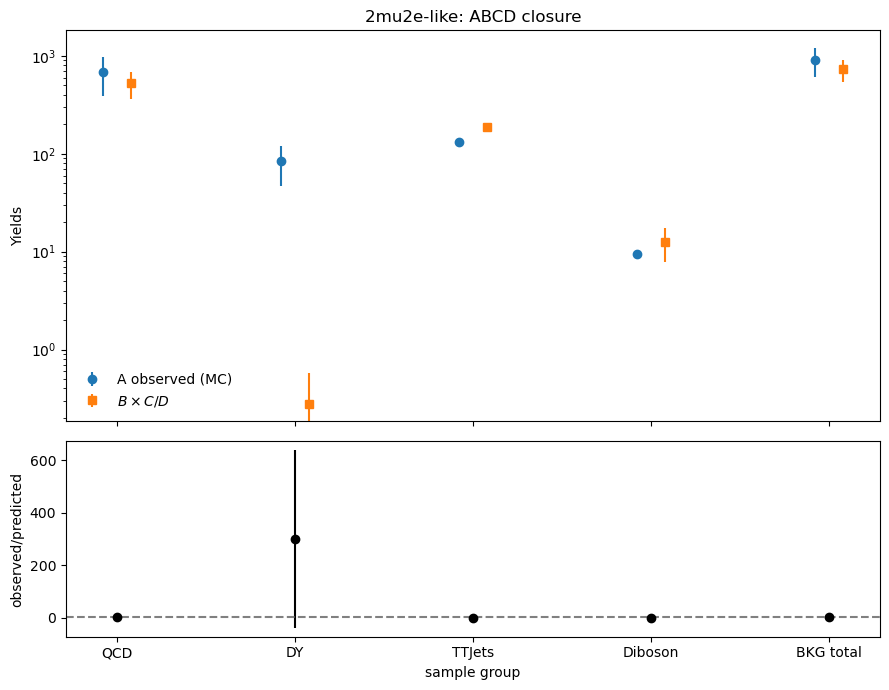

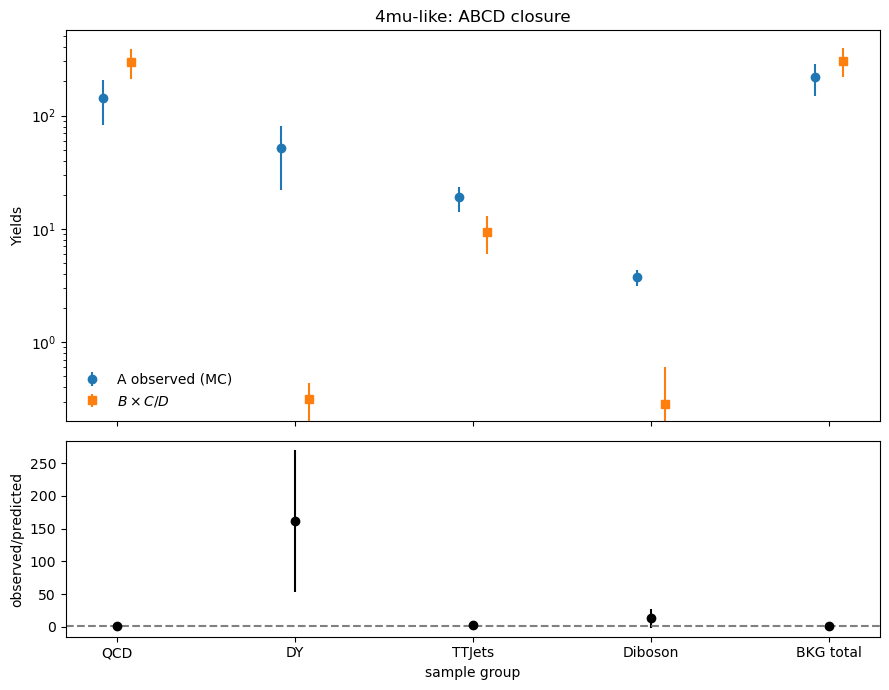

In [19]:
def plot_closure(summary, topology):
    frame = summary[(summary.topology == topology) & summary.group.isin(["QCD", "DY", "TTJets", "Diboson", "BKG total"])].copy()
    x = np.arange(len(frame))
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].errorbar(x-0.08, frame.A, yerr=frame.A_err, fmt="o", label="A observed (MC)")
    axes[0].errorbar(x+0.08, frame.A_pred, yerr=frame.A_pred_err, fmt="s", label=r"$B\times C/D$")
    axes[0].set(ylabel="Yields", title=f"{topology}: ABCD closure")
    axes[0].set_yscale("log")
    axes[0].legend(frameon=False)
    axes[1].errorbar(x, frame.closure, yerr=frame.closure_err, fmt="o", color="black")
    axes[1].axhline(1, color="gray", ls="--")
    axes[1].set(ylabel="observed/predicted", xticks=x, xticklabels=frame.group, xlabel="sample group")
    fig.tight_layout()


for topology in abcd_summary.topology.unique():
    plot_closure(abcd_summary, topology)
    plt.show()


## 6. Working-point stability


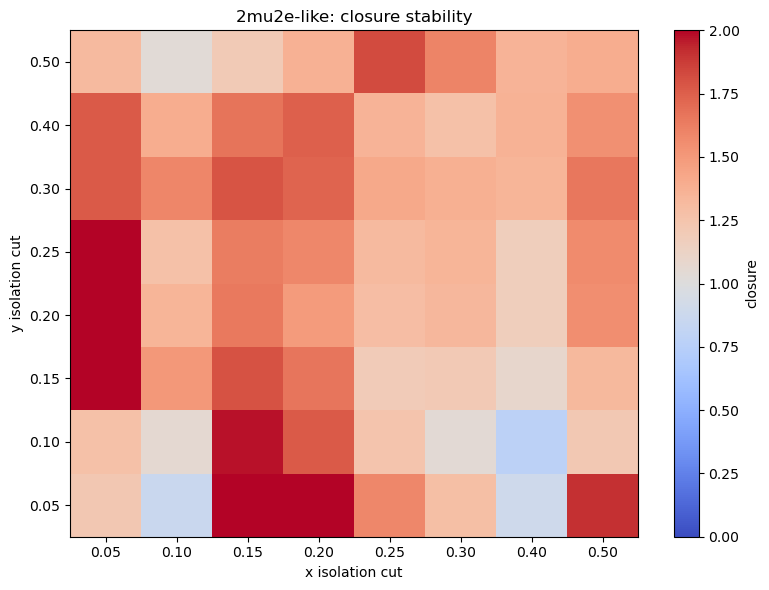

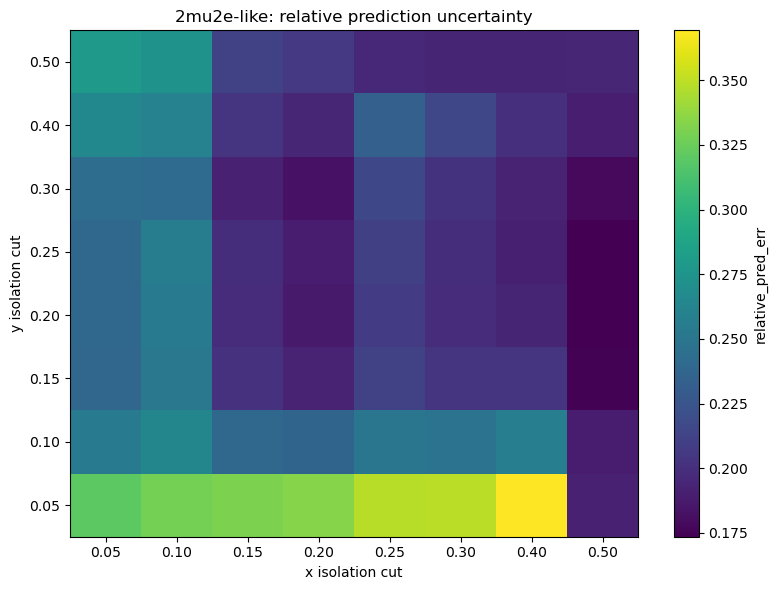

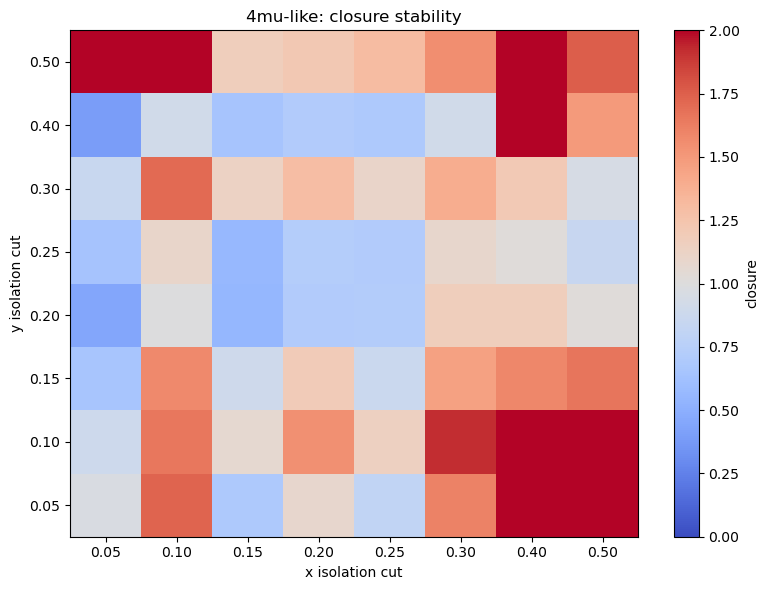

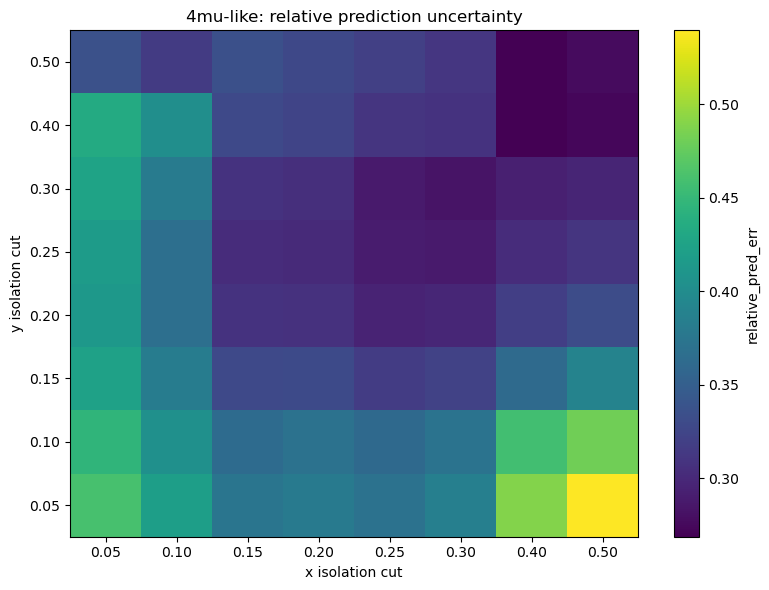

In [20]:
def scan_working_points(h2d, xcuts, ycuts):
    rows = []
    for xcut in xcuts:
        for ycut in ycuts:
            yields, pred, pred_err, ratio, ratio_err = closure_result(h2d, (xcut, ycut))
            rows.append({"xcut": xcut, "ycut": ycut, "A": yields["A"][0],
                         "A_pred": pred, "A_pred_err": pred_err,
                         "relative_pred_err": pred_err/pred if pred > 0 else np.nan,
                         "closure": ratio, "closure_err": ratio_err,
                         "min_control_yield": min(yields[r][0] for r in ["B", "C", "D"])})
    return pd.DataFrame(rows)


def plot_scan_heatmap(scan, value, title, cmap="viridis", vmin=None, vmax=None):
    table = scan.pivot(index="ycut", columns="xcut", values=value)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(table.values, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)), labels=[f"{x:.2f}" for x in table.columns])
    ax.set_yticks(np.arange(len(table.index)), labels=[f"{y:.2f}" for y in table.index])
    ax.set(xlabel="x isolation cut", ylabel="y isolation cut", title=title)
    fig.colorbar(im, ax=ax, label=value)
    fig.tight_layout()


wp_scans = {}
for hist_name, cfg in HIST_CONFIGS.items():
    h2d = group_hist("BKG total", hist_name)
    if h2d is None:
        continue
    scan = scan_working_points(h2d, SCAN_VALUES, SCAN_VALUES)
    wp_scans[hist_name] = scan
    plot_scan_heatmap(scan, "closure", f"{cfg['topology']}: closure stability", cmap="coolwarm", vmin=0, vmax=2)
    plt.show()
    plot_scan_heatmap(scan, "relative_pred_err", f"{cfg['topology']}: relative prediction uncertainty")
    plt.show()


## 7. Correlation diagnostics


In [11]:
def weighted_corr_from_hist2d(h2d):
    weights, _ = hist_values_variances(h2d)
    x, y = np.meshgrid(h2d.axes[0].centers, h2d.axes[1].centers, indexing="ij")
    mask = np.isfinite(weights) & (weights > 0)
    if not mask.any():
        return np.nan
    w, xv, yv = weights[mask], x[mask], y[mask]
    mx, my = np.average(xv, weights=w), np.average(yv, weights=w)
    cov = np.average((xv-mx)*(yv-my), weights=w)
    vx = np.average((xv-mx)**2, weights=w)
    vy = np.average((yv-my)**2, weights=w)
    return cov/np.sqrt(vx*vy) if vx > 0 and vy > 0 else np.nan


corr_rows = []
for hist_name, cfg in HIST_CONFIGS.items():
    for group in GROUP_ORDER:
        h2d = group_hist(group, hist_name)
        if h2d is not None:
            corr_rows.append({"topology": cfg["topology"], "group": group,
                              "weighted_Pearson": weighted_corr_from_hist2d(h2d)})
correlation_summary = pd.DataFrame(corr_rows)
display(correlation_summary.pivot(index="group", columns="topology", values="weighted_Pearson"))


topology,2mu2e-like,4mu-like
group,,
BKG total,0.051492,0.170134
DY,-0.220800,0.102813
Data,0.076168,0.669971
Diboson,-0.048911,0.310795
QCD,0.052708,0.163774
TTJets,-0.043995,0.117892


## 8. Data-driven prediction

Data의 B/C/D로부터 A를 예측한다. `UNBLIND_DATA_A=False`이면 observed A와 Data closure는 표에 노출하지 않는다. 향후 non-QCD subtraction은 이 단계 앞에 추가한다.


In [12]:
data_prediction = abcd_summary[abcd_summary.group == "Data"][
    ["topology", "B", "B_err", "C", "C_err", "D", "D_err",
     "A_pred", "A_pred_err", "A", "A_err", "closure", "closure_err"]
].copy()
display(data_prediction)


,topology,B,B_err,C,C_err,D,D_err,A_pred,A_pred_err,A,A_err,closure,closure_err
5,2mu2e-like,2462.0,49.618545,7673.0,87.595662,17891.0,133.757243,1055.889889,25.699479,NaN,NaN,NaN,NaN
11,4mu-like,708.0,26.608269,1606.0,40.074930,5211.0,72.187256,218.201497,10.297160,NaN,NaN,NaN,NaN


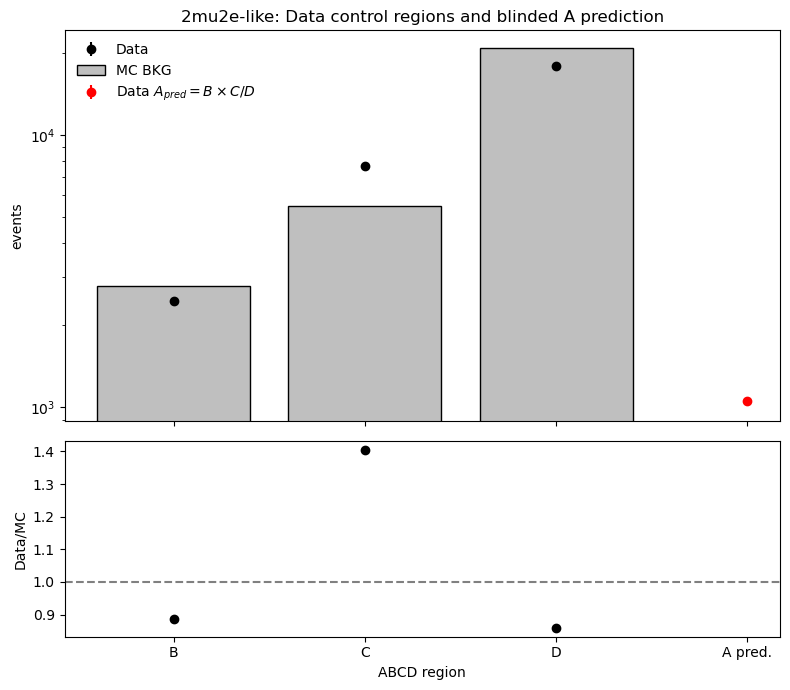

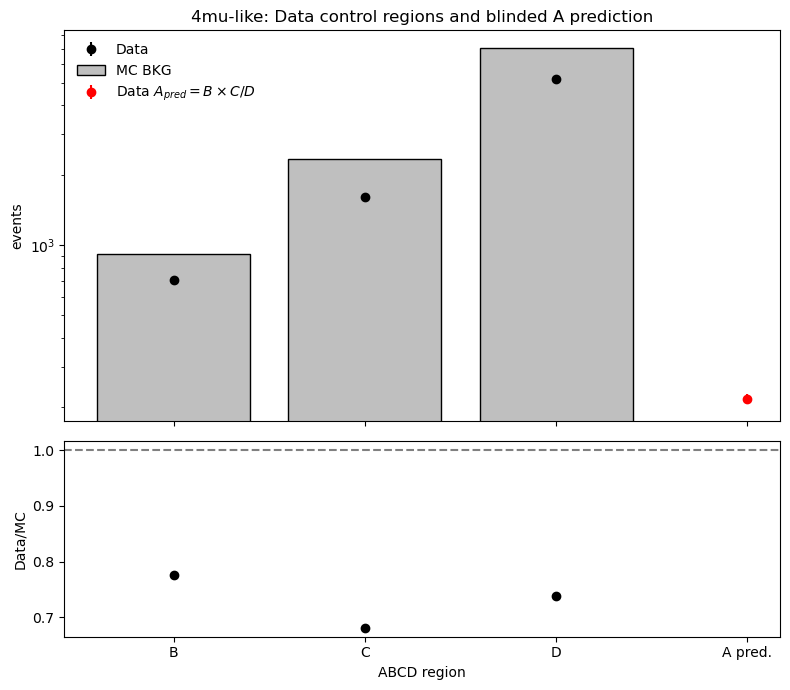

In [21]:
def plot_data_control_regions(summary, topology):
    data = summary[(summary.topology == topology) & (summary.group == "Data")].iloc[0]
    bkg = summary[(summary.topology == topology) & (summary.group == "BKG total")].iloc[0]
    regions = ["B", "C", "D"]
    x = np.arange(len(regions))
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].errorbar(x, [data[r] for r in regions], yerr=[data[f"{r}_err"] for r in regions],
                     fmt="o", color="black", label="Data")
    axes[0].bar(x, [bkg[r] for r in regions], color="0.75", edgecolor="black", label="MC BKG")
    axes[0].errorbar([3], [data.A_pred], yerr=[data.A_pred_err], fmt="o", color="red",
                     label=r"Data $A_{pred}=B\times C/D$")
    axes[0].set_yscale("log")
    axes[0].set(ylabel="events", title=f"{topology}: Data control regions and blinded A prediction")
    axes[0].legend(frameon=False)
    ratio = np.array([data[r]/bkg[r] if bkg[r] != 0 else np.nan for r in regions])
    axes[1].plot(x, ratio, "o", color="black")
    axes[1].axhline(1, color="gray", ls="--")
    axes[1].set(ylabel="Data/MC", xticks=[0, 1, 2, 3], xticklabels=["B", "C", "D", "A pred."], xlabel="ABCD region")
    fig.tight_layout()


for topology in data_prediction.topology:
    plot_data_control_regions(abcd_summary, topology)
    plt.show()


## 9. MC non-closure and κ-corrected Data prediction

MC에서 $\kappa=N_A N_D/(N_B N_C)=N_A/N_A^{pred}$를 측정한다. raw Data prediction은 control-region Data만 사용하며, κ-corrected 값은 MC non-closure를 중앙값 보정으로 적용한 machinery 검증 결과다. 최종 분석에서는 κ를 correction으로 쓸지 systematic으로 쓸지 별도로 결정해야 한다. Data A는 사용하지 않는다.


,topology,kappa_MC,kappa_MC_err,Data_A_raw_pred,Data_A_raw_pred_err,Data_A_kappa_pred,Data_A_kappa_pred_err,MC_nonclosure_fraction
0,2mu2e-like,1.244515,0.512753,1055.889889,25.699479,1314.071081,542.354667,0.244515
1,4mu-like,0.714625,0.306243,218.201497,10.297160,155.932143,67.226535,0.285375


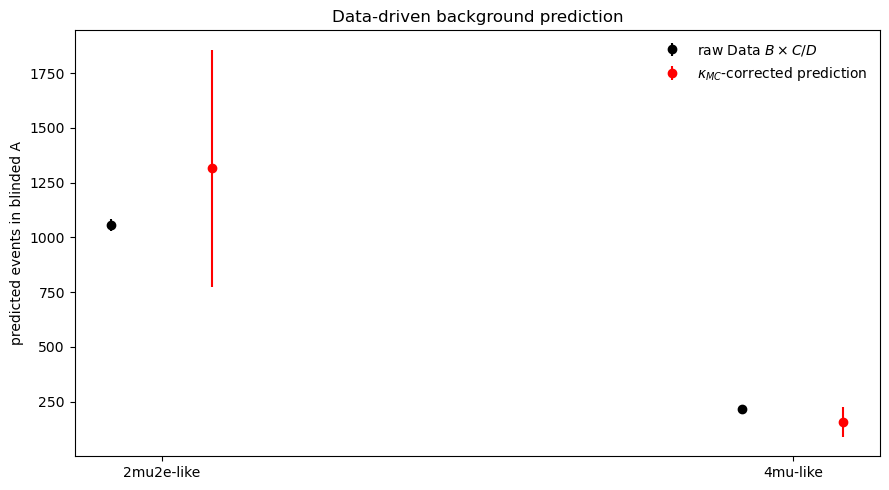

In [22]:
kappa_rows = []
for topology in data_prediction.topology:
    data = abcd_summary[(abcd_summary.topology == topology) & (abcd_summary.group == "Data")].iloc[0]
    bkg = abcd_summary[(abcd_summary.topology == topology) & (abcd_summary.group == "BKG total")].iloc[0]
    kappa, kappa_err = bkg.closure, bkg.closure_err
    corrected = kappa * data.A_pred
    corrected_err = abs(corrected) * np.sqrt(
        (kappa_err/kappa)**2 + (data.A_pred_err/data.A_pred)**2
    ) if kappa > 0 and data.A_pred > 0 else np.nan
    kappa_rows.append({
        "topology": topology, "kappa_MC": kappa, "kappa_MC_err": kappa_err,
        "Data_A_raw_pred": data.A_pred, "Data_A_raw_pred_err": data.A_pred_err,
        "Data_A_kappa_pred": corrected, "Data_A_kappa_pred_err": corrected_err,
        "MC_nonclosure_fraction": abs(kappa - 1),
    })
kappa_summary = pd.DataFrame(kappa_rows)
display(kappa_summary)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(kappa_summary))
ax.errorbar(x-0.08, kappa_summary.Data_A_raw_pred, yerr=kappa_summary.Data_A_raw_pred_err,
            fmt="o", color="black", label=r"raw Data $B\times C/D$")
ax.errorbar(x+0.08, kappa_summary.Data_A_kappa_pred, yerr=kappa_summary.Data_A_kappa_pred_err,
            fmt="o", color="red", label=r"$\kappa_{MC}$-corrected prediction")
ax.set(xticks=x, xticklabels=kappa_summary.topology, ylabel="predicted events in blinded A",
       title="Data-driven background prediction")
ax.legend(frameon=False)
fig.tight_layout()


## 10. Full-signal A concentration and control-region leakage

각 benchmark는 대응하는 reconstruction topology histogram에서 평가한다. 아래 값은 해당 2D isolation histogram에 진입한 signal의 **조건부 region fraction**이며 전체 selection efficiency는 아니다. Signal A는 빨강, B/C/D leakage는 각각 파랑·주황·초록으로 표시한다.


,signal,topology,total_2D_yield,A_fraction,B_fraction,C_fraction,D_fraction,control_leakage_fraction
0,2Mu2E_500GeV_0p25GeV_2p0mm,2mu2e-like,7.149865,0.871369,0.010607,0.116502,0.001522,0.128631
1,4Mu_500GeV_0p25GeV_2p0mm,4mu-like,8.398699,0.970251,0.003360,0.026144,0.000245,0.029749


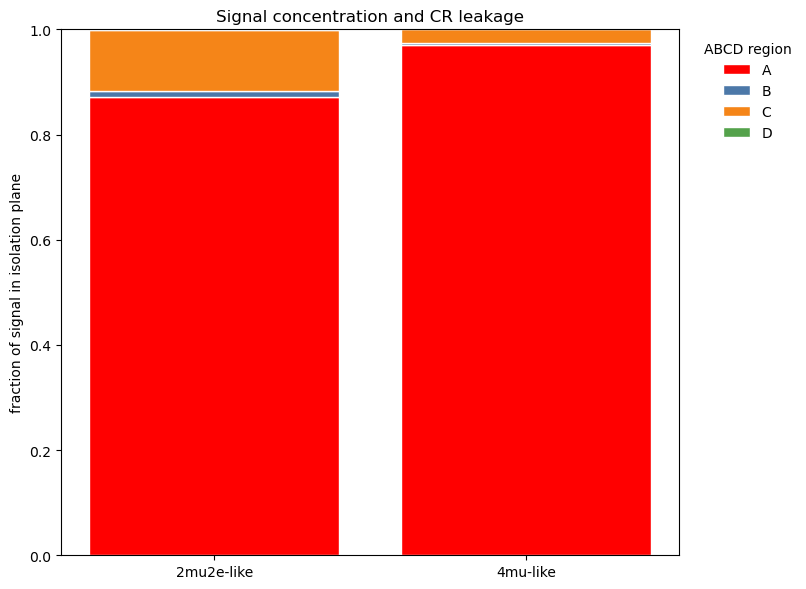

In [24]:
SIGNAL_HISTOGRAM = {
    "2Mu2E_500GeV_0p25GeV_2p0mm": "mulj_egmlj_iso",
    "4Mu_500GeV_0p25GeV_2p0mm": "mulj_mulj_iso",
}
signal_rows = []
for signal in loaded_signals:
    hist_name = SIGNAL_HISTOGRAM[signal]
    h2d = group_hist(signal, hist_name)
    yields = abcd_yields(h2d, HIST_CONFIGS[hist_name]["cuts"])
    total = sum(yields[region][0] for region in ["A", "B", "C", "D"])
    row = {"signal": signal, "topology": HIST_CONFIGS[hist_name]["topology"], "total_2D_yield": total}
    for region in ["A", "B", "C", "D"]:
        row[f"{region}_fraction"] = yields[region][0]/total if total > 0 else np.nan
    row["control_leakage_fraction"] = 1 - row["A_fraction"] if total > 0 else np.nan
    signal_rows.append(row)
signal_region_summary = pd.DataFrame(signal_rows)
display(signal_region_summary)

if not signal_region_summary.empty:
    regions = ["A", "B", "C", "D"]
    colors = ["red", "#4C78A8", "#F58518", "#54A24B"]
    x = np.arange(len(signal_region_summary))
    bottom = np.zeros(len(signal_region_summary))
    fig, ax = plt.subplots(figsize=(10, 6))
    for region, color in zip(regions, colors):
        values = signal_region_summary[f"{region}_fraction"].to_numpy()
        ax.bar(x, values, bottom=bottom, color=color, edgecolor="white", label=region)
        bottom += values
    ax.set(xticks=x, xticklabels=signal_region_summary.topology, ylim=(0, 1),
           ylabel="fraction of signal in isolation plane", title="Signal concentration and CR leakage")
    ax.legend(frameon=False, ncol=1, loc="upper left", bbox_to_anchor=(1.02, 1.0), title="ABCD region")
    fig.tight_layout(rect=(0, 0, 0.82, 1))


## 11. Final summary and hand-off to `05`

아래 표가 이 notebook의 최종 산출물이다. `05`에서는 `base_old` 대신 정식 SR/VR output을 로드하고 동일한 계산 및 plotting 함수를 재사용한다.


In [16]:
final_summary = abcd_summary[abcd_summary.group.isin(["BKG total", "Data"])][
    ["topology", "group", "A", "A_err", "A_pred", "A_pred_err", "closure", "closure_err"]
].reset_index(drop=True)
print("Background closure and blinded Data prediction")
display(final_summary)
print("MC non-closure and corrected Data prediction")
display(kappa_summary)
print("Full-signal region fractions")
display(signal_region_summary)

print("Pipeline complete. Next: replace the input/channel layer with processed SR/VR outputs in notebook 05.")


Background closure and blinded Data prediction


,topology,group,A,A_err,A_pred,A_pred_err,closure,closure_err
0,2mu2e-like,BKG total,907.429927,296.694425,729.143270,182.793774,1.244515,0.512753
1,2mu2e-like,Data,NaN,NaN,1055.889889,25.699479,NaN,NaN
2,4mu-like,BKG total,218.140042,69.022101,305.251263,88.220725,0.714625,0.306243
3,4mu-like,Data,NaN,NaN,218.201497,10.297160,NaN,NaN


MC non-closure and corrected Data prediction


,topology,kappa_MC,kappa_MC_err,Data_A_raw_pred,Data_A_raw_pred_err,Data_A_kappa_pred,Data_A_kappa_pred_err,MC_nonclosure_fraction
0,2mu2e-like,1.244515,0.512753,1055.889889,25.699479,1314.071081,542.354667,0.244515
1,4mu-like,0.714625,0.306243,218.201497,10.297160,155.932143,67.226535,0.285375


Full-signal region fractions


,signal,topology,total_2D_yield,A_fraction,B_fraction,C_fraction,D_fraction,control_leakage_fraction
0,2Mu2E_500GeV_0p25GeV_2p0mm,2mu2e-like,7.149865,0.871369,0.010607,0.116502,0.001522,0.128631
1,4Mu_500GeV_0p25GeV_2p0mm,4mu-like,8.398699,0.970251,0.003360,0.026144,0.000245,0.029749


Pipeline complete. Next: replace the input/channel layer with processed SR/VR outputs in notebook 05.
